# **"Internship task by Decodelabs"**

- **Intership Duration : 25th-April-2026 - 25th-May-2026**

- **Project : 4**

     **Task : 1 - Data Collection & Data Understanding**

     **Task : 2 - Data Cleaning & Preprocessing**

     **Task : 3 - Exploratory Data Analysis (EDA)**


     **Task : 4 - Data Visulization**

     **Task : 5 - Predictive Model or Insight Project**

- **Data Source : From Kaggle**

- **DataSet Name :  Body Signal of Smoking**

- **Domain : Data Science**

- **Submitted By : Palwasha Mushtaq**

# **Introduction – Body Signal of Smoking Dataset**

**The Body Signal of Smoking dataset is used to analyze and predict smoking behavior based on different health and biometric indicators of individuals. It includes features such as age, height, weight, blood pressure, cholesterol levels, and other body signals that reflect a person’s physical condition.**

**The main goal of this dataset is to identify patterns in body health data that can help classify whether a person is a smoker or a non-smoker. Machine learning models can be applied to detect these patterns and make accurate predictions.**

**This project is useful for:**

- **Understanding the relationship between smoking and health indicators.**
- **Building a binary classification model (Smoker vs Non-Smoker).**
- **Practicing data preprocessing and feature analysis.**

**Quick Medical Glossary (For Non-Medical Readers)**

- **Systolic (Blood Pressure - high pressure)**
- **Triglyceride (Cholesterol system-)**
- **HDL (Good cholesterol)**
- **LDL (Bad cholesterol)**
- **Hemoglobin (Blood health)**
- **AST / ALT / GTP (Liver function)**
- **AST → liver + muscle damage**
- **ALT → liver-specific damage**
- **GTP (GGT) → alcohol/smoking/liver stress marker**
- **Serum Creatinine(Kidney function)**
- **Oral (mouth health indicator - usually dental check feature)**
- **Tartar (Hard yellow buildup on teeth, which forms much faster in smokers due to nicotine.)**

# **Import Libraries**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


# **LOAD DATASET**

In [2]:
df = pd.read_csv('smoking.csv')
print(df.head(10))

   ID gender  age  height(cm)  weight(kg)  waist(cm)  eyesight(left)  \
0   0      F   40         155          60       81.3             1.2   
1   1      F   40         160          60       81.0             0.8   
2   2      M   55         170          60       80.0             0.8   
3   3      M   40         165          70       88.0             1.5   
4   4      F   40         155          60       86.0             1.0   
5   5      M   30         180          75       85.0             1.2   
6   6      M   40         160          60       85.5             1.0   
7   7      M   45         165          90       96.0             1.2   
8   9      F   50         150          60       85.0             0.7   
9  10      M   45         175          75       89.0             1.0   

   eyesight(right)  hearing(left)  hearing(right)  ...  hemoglobin  \
0              1.0              1               1  ...        12.9   
1              0.6              1               1  ...        12.7 

# **DATA OVERVIEW**

In [3]:
print('DATA SHAPE:\n', df.shape)
print('==========================================================================')
print('DATA COLUMNS:\n', df.columns)
print('==========================================================================')
print('DATA INFORMATION:\n',df.info())
print('==========================================================================')
print('DESCRIPTIVE STATISTICS SUMMARY:\n',df.describe())
print('==========================================================================')
print('CHCEK IMBALANCE:\n',df['smoking'].value_counts(normalize=True)*100)


DATA SHAPE:
 (55692, 27)
DATA COLUMNS:
 Index(['ID', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)',
       'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol',
       'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'AST', 'ALT', 'Gtp', 'oral', 'dental caries',
       'tartar', 'smoking'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  str    
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7

**This dataset contains 55,692 records and 27 features, collected to predict whether a person is a smoker or non-smoker based on their physical and medical health indicators.**

**It includes information such as age, gender, body measurements (height, weight, waist), blood pressure, cholesterol levels, liver enzymes, kidney function tests, eyesight, hearing, and dental health. These features represent overall human health conditions that may be influenced by smoking habits.**

**The target variable is mildly imbalanced (63% non-smokers, 37% smokers).**

# **Data Preprocessing**

- **Check missing values**
- **Check Duplicates Values**

In [4]:
print('CHECK MISSING VALUES:\n',df.isnull().sum())
print('==========================================================================')
print('CHECK DUPLICATES VALUES:\n',df.duplicated().sum())

CHECK MISSING VALUES:
 ID                     0
gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
oral                   0
dental caries          0
tartar                 0
smoking                0
dtype: int64
CHECK DUPLICATES VALUES:
 0


**The dataset is completely clean and well-structured, with no missing values and no duplicate records across all 55,692 entries.**

**This means:**
- **No data cleaning (imputation) is required.**
- **No duplicate removal is needed.**
- **Dataset is ready for preprocessing and modeling.**

- **Drop Unnecessary Column**

In [5]:
df.drop(columns=['ID','oral'], inplace=True)
print(df)

      gender  age  height(cm)  weight(kg)  waist(cm)  eyesight(left)  \
0          F   40         155          60       81.3             1.2   
1          F   40         160          60       81.0             0.8   
2          M   55         170          60       80.0             0.8   
3          M   40         165          70       88.0             1.5   
4          F   40         155          60       86.0             1.0   
...      ...  ...         ...         ...        ...             ...   
55687      F   40         170          65       75.0             0.9   
55688      F   45         160          50       70.0             1.2   
55689      F   55         160          50       68.5             1.0   
55690      M   60         165          60       78.0             0.8   
55691      M   55         160          65       85.0             0.9   

       eyesight(right)  hearing(left)  hearing(right)  systolic  ...  LDL  \
0                  1.0              1               1     

**The "id" and "Oral" columns were dropped as it is irrelevant for analysis and does not contribute to the prediction.**

# **Exploratory Data Analysis**

- **Statistical Analysis**

In [6]:
df.groupby('smoking').mean(numeric_only=True)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
smoking,,,,,,,,,,,,,,,,,,,,,
0,45.677981,161.870477,62.907455,80.447669,0.989920,0.984110,1.028379,1.028436,120.732440,75.206090,...,112.921957,59.294492,116.374549,14.144990,1.082811,0.849144,25.309135,24.740897,30.885859,0.180918
1,41.607431,169.436324,70.959668,84.800518,1.051733,1.047636,1.020777,1.022195,122.806502,77.380787,...,150.341481,53.837888,112.535468,15.445339,1.094793,0.948775,27.688194,30.989782,55.570423,0.269176


**This grouped analysis compares average health indicators between non-smokers (0) and smokers (1).***

**Overall, the data shows clear health differences:**

- **Smokers have higher triglycerides, blood pressure, and liver enzymes (AST, ALT, Gtp)**
- **Smokers also show lower HDL (good cholesterol)**
- **Hemoglobin is slightly higher in smokers**
- **Dental problems are more common in smokers**

**Non-smokers generally show better overall health indicators, especially in cardiovascular and liver-related features.**

- **Data Visualization**

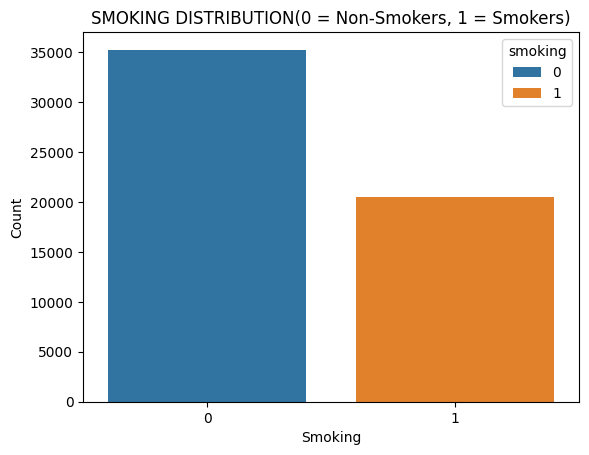

In [7]:
sns.countplot(x='smoking',hue='smoking', data = df)
plt.title('SMOKING DISTRIBUTION(0 = Non-Smokers, 1 = Smokers)')
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.show()

**The count plot illustrates the smoking distribution within the dataset, where 0 represents non-smokers and 1 represents smokers. It shows that the majority of individuals are non-smokers (over 35,000), while the number of smokers is significantly lower (around 20,500).**

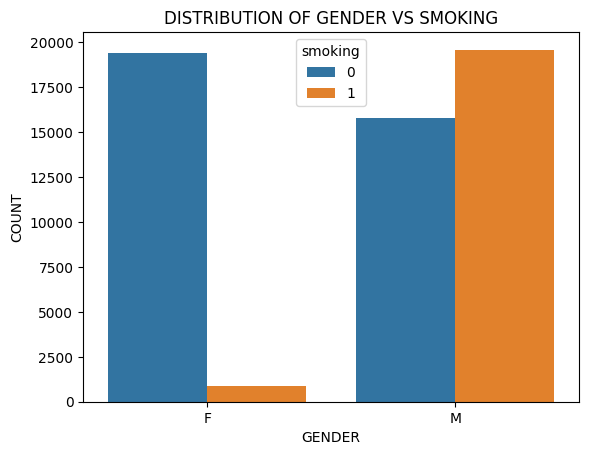

In [8]:
sns.countplot(x='gender',hue = 'smoking',data=df)
plt.title('DISTRIBUTION OF GENDER VS SMOKING')
plt.xlabel('GENDER')
plt.ylabel('COUNT')
plt.show()

**This clustered count plot shows the relationship between gender and smoking habits (0 = non-smokers, 1 = smokers). It reveals a major difference between the groups: the vast majority of females are non-smokers, with a very small count of smokers. Conversely, among males, the number of smokers is higher than non-smokers, making males the predominant smoking group in this dataset.**

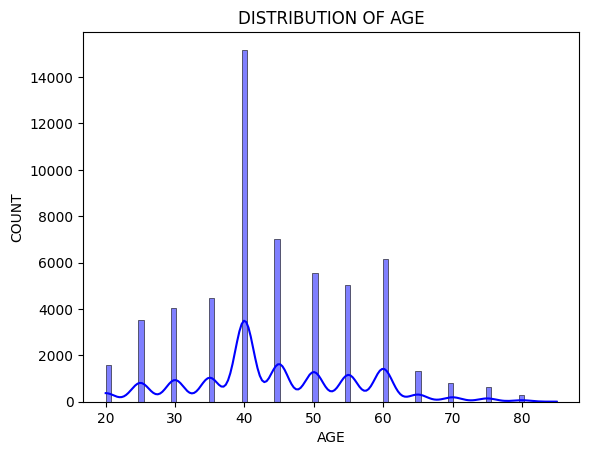

In [9]:
sns.histplot(df['age'], kde=True, color='blue')
plt.title('DISTRIBUTION OF AGE')
plt.xlabel('AGE')
plt.ylabel('COUNT')
plt.show()

**The distribution plot shows that most individuals are between 40–60 years old, with the highest concentration around age 40. Fewer people are present in very young and older age groups.**

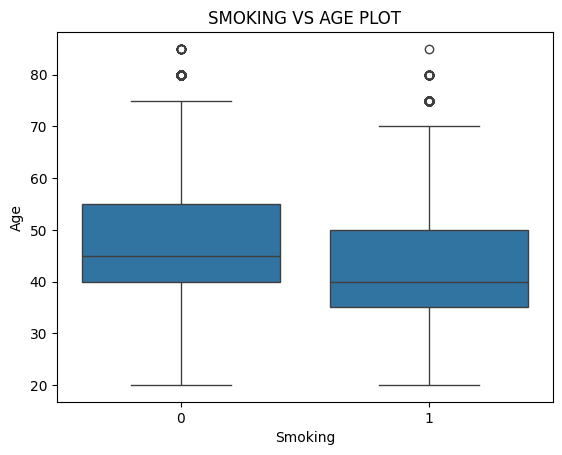

In [10]:
sns.boxplot(x='smoking', y='age', data=df)
plt.title('SMOKING VS AGE PLOT')
plt.xlabel('Smoking')
plt.ylabel('Age')
plt.show()

**The boxplot compares age based on smoking status. Non-smokers have a slightly higher median age than smokers, indicating that smokers in the dataset are generally younger on average.**

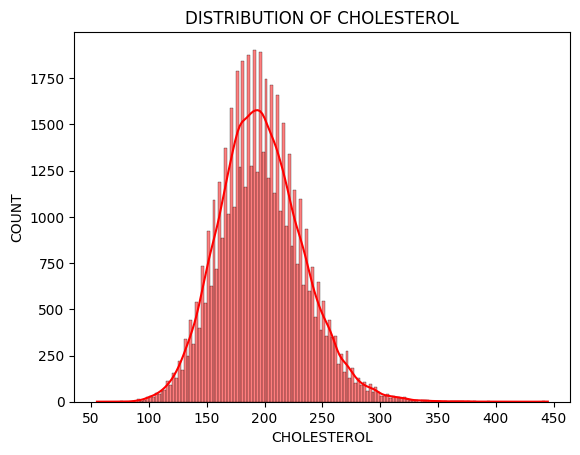

In [11]:
sns.histplot(df['Cholesterol'], kde=True, color='red')
plt.title('DISTRIBUTION OF CHOLESTEROL')
plt.xlabel('CHOLESTEROL')
plt.ylabel('COUNT')
plt.show()

**The distribution plot shows that cholesterol levels follow a bell-shaped, approximately normal distribution. The highest concentration of individuals lies between 150 and 250, with the peak occurring around 190–200. Extremely low (under 100) or extremely high (above 300) cholesterol levels are rare in this dataset.**

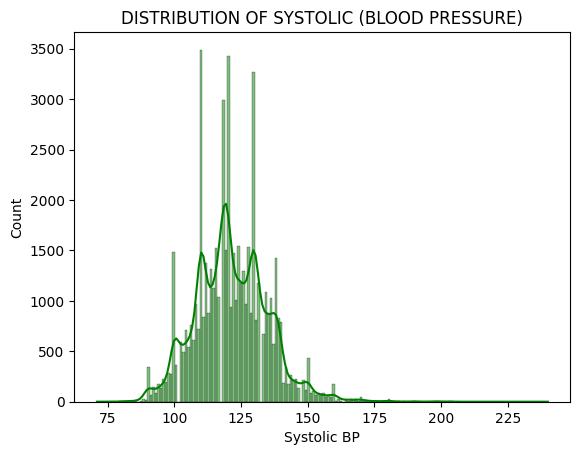

In [12]:
sns.histplot(df['systolic'], kde=True, color='green')
plt.title('DISTRIBUTION OF SYSTOLIC (BLOOD PRESSURE)')
plt.xlabel('Systolic BP')
plt.ylabel('Count')
plt.show()

**The distribution plot shows that most individuals have a systolic blood pressure concentrated between 110 and 140. There are sharp, prominent peaks at specific intervals like 110, 120, and 130, which suggests data rounding or standard measurement tendencies. Extremely low systolic BP (under 90) or exceptionally high levels (above 160) are quite rare in this dataset.**

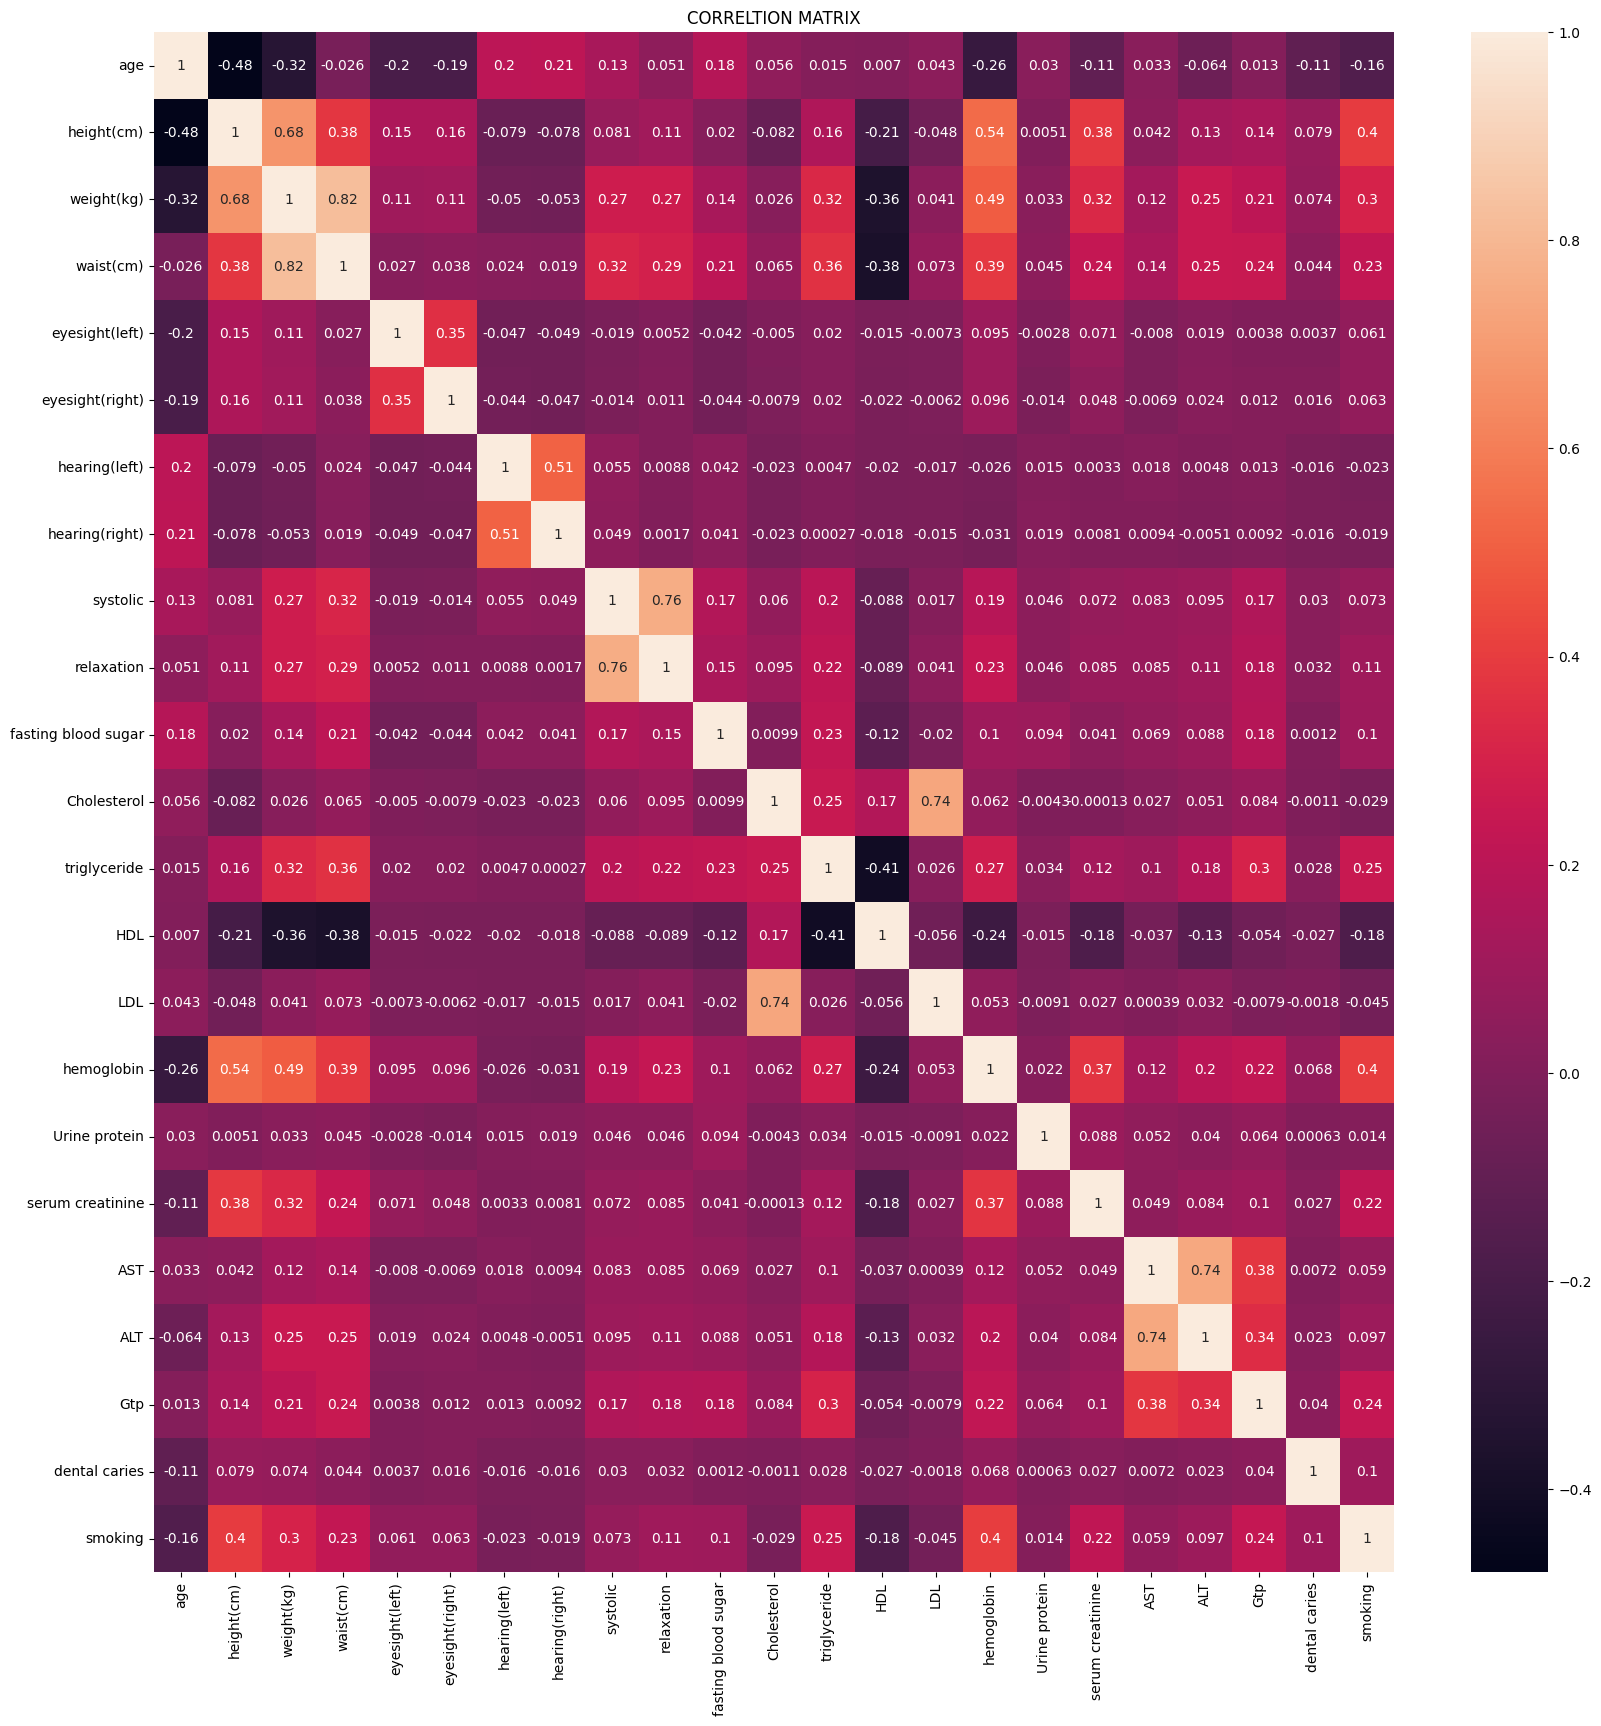

In [13]:
plt.figure(figsize= (20,20))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('CORRELTION MATRIX')
plt.show()

**The correlation matrix heatmap displays the linear relationships between various health metrics. Strongest positive correlations (indicated by light peach/cream colors) are visible between physical measurements like weight and waist circumference (0.82), and clinical markers like Cholesterol and LDL (0.74), or AST and ALT (0.74). Conversely, a notable negative correlation appears between HDL ("good" cholesterol) and triglycerides (-0.41), shown in dark purple.**

- **Encoding**

In [14]:
le = LabelEncoder()
df[['gender','tartar']]=df[['gender','tartar']].apply(le.fit_transform)
print('LABEL ENCODING')
print(df[['gender','tartar']])

LABEL ENCODING
       gender  tartar
0           0       1
1           0       1
2           1       0
3           1       1
4           0       0
...       ...     ...
55687       0       1
55688       0       1
55689       0       0
55690       1       0
55691       1       1

[55692 rows x 2 columns]


- **Standard Scaler**

In [15]:
standardscaler = StandardScaler()
col = df[['gender','age','height(cm)','weight(kg)','waist(cm)','eyesight(left)','eyesight(right)','hearing(left)','hearing(right)','systolic','relaxation','fasting blood sugar','Cholesterol','triglyceride','HDL','LDL','hemoglobin','Urine protein','serum creatinine','AST','ALT','Gtp','dental caries','tartar']]
standardscaled = standardscaler.fit_transform(col)
print('STANDARD SCALER APPLIED')
print(standardscaled)

STANDARD SCALER APPLIED
[[-1.32085772 -0.34651724 -1.04946503 ... -0.25754979 -0.52075676
   0.89442719]
 [-1.32085772 -0.34651724 -0.50566252 ... -0.4365115  -0.52075676
   0.89442719]
 [ 0.75708381  0.8960986   0.58194251 ... -0.35697296 -0.52075676
  -1.11803399]
 ...
 [-1.32085772  0.8960986  -0.50566252 ... -0.55581931 -0.52075676
  -1.11803399]
 [ 0.75708381  1.31030388  0.03814    ... -0.4365115  -0.52075676
  -1.11803399]
 [ 0.75708381  0.8960986  -0.50566252 ...  0.02083509 -0.52075676
   0.89442719]]


**StandardScaler is applied to numerical features like 'gender','age','height(cm)','weight(kg)','waist(cm)','eyesight(left)','eyesight(right)','hearing(left)','hearing(right)','systolic','relaxation','fasting blood sugar','Cholesterol','triglyceride','HDL','LDL','hemoglobin','Urine protein','serum creatinine','AST','ALT','Gtp','dental caries','tartar' to normalize their values. This ensures that all features are on a similar scale, which helps the model perform more effectively and improves convergence.**

- **Split the Data For Training and Testing**

In [16]:
X = df.drop('smoking',axis = 1)
y = df['smoking']
X_train, X_test,y_train,y_test = train_test_split(X , y, test_size = 0.2, random_state= 42)
print("Training Data")
print(X_train)
print("Testing Data")
print(X_test)

Training Data
       gender  age  height(cm)  weight(kg)  waist(cm)  eyesight(left)  \
10126       1   60         165          55       76.0             1.0   
2467        1   40         175          80       94.0             1.0   
36288       1   35         180          90       98.0             1.2   
32339       1   40         175          70       77.8             1.0   
29452       1   45         175          65       78.0             1.5   
...       ...  ...         ...         ...        ...             ...   
44732       1   25         170          80       82.0             1.0   
54343       1   45         165          55       70.0             0.7   
38158       1   35         180          75       86.7             1.2   
860         0   55         155          60       86.0             0.8   
15795       1   55         180          70       81.0             1.0   

       eyesight(right)  hearing(left)  hearing(right)  systolic  ...  HDL  \
10126              1.0          

**This dataset is split into Training Data (80%) and Testing Data (20%) across a total of 55,692 records with 24 columns. It contains comprehensive medical and physical metrics—such as age, weight, blood pressure, cholesterol, and dental health indicators—typically used to build and evaluate predictive machine learning models.**

# **Model Building**

- **Logistic Regression Model**

In [17]:
lr_model = LogisticRegression(max_iter=2000,solver='saga')
lr_model.fit(X_train, y_train)

c:\Users\Aaqeeb Mushtaq\.conda\envs\PYTHON\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr)

[0 0 1 ... 0 1 1]


**A Logistic Regression model is built and trained using fit() to learn health patterns from the training data. Once trained, the model predicts outcomes for the test data, generating the final binary array (0 0 1 0 1 1) where each individual is classified into one of two categories: 0 (Negative class/Non-smoker) or 1 (Positive class/Smoker).**

- **Random Forest**

In [19]:
RF_model = RandomForestClassifier(random_state=42)
RF_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
y_pred_RF = RF_model.predict(X_test)
print(y_pred_RF)

[0 0 1 ... 0 0 1]


**A Random Forest Classifier is built and trained using fit() to learn patterns by combining multiple decision trees. After training, the model predicts outcomes for the test data, generating the binary array [0 0 1 ... 0 0 1] where each individual is classified as either 0 or 1.**

- **XGBOOST Classifier**

In [35]:
XGB_model = XGBClassifier(random_state = 42)
XGB_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [36]:
y_pred_XGB = XGB_model.predict(X_test)
print(y_pred_XGB)

[0 0 1 ... 0 0 1]


**An XGBoost Classifier (Gradient Boosting model) is built and trained using fit() to learn patterns by sequentially correcting errors from weak decision trees. After training, the model predicts outcomes for the test data, generating the binary array [0 0 1 ... 0 0 1] where each individual is classified as either 0 or 1.**

- **Classification Report**

In [37]:
print('LOGISTIC REGRESSION CLASSIFIER REPORT:\n', classification_report(y_test,y_pred_lr))
print('RANDOM FOREST CLASSIFICATION REPORT:\n', classification_report(y_test, y_pred_RF))
print('XGBOOST CLASSIFICTION REPORT:\n', classification_report(y_test,y_pred_XGB))

LOGISTIC REGRESSION CLASSIFIER REPORT:
               precision    recall  f1-score   support

           0       0.75      0.82      0.79      7027
           1       0.64      0.54      0.59      4112

    accuracy                           0.72     11139
   macro avg       0.70      0.68      0.69     11139
weighted avg       0.71      0.72      0.71     11139

RANDOM FOREST CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87      7027
           1       0.76      0.80      0.78      4112

    accuracy                           0.83     11139
   macro avg       0.82      0.83      0.82     11139
weighted avg       0.84      0.83      0.84     11139

XGBOOST CLASSIFICTION REPORT:
               precision    recall  f1-score   support

           0       0.84      0.81      0.82      7027
           1       0.69      0.73      0.71      4112

    accuracy                           0.78     11139
   macro avg       

**Model Comparsion Summary:**

**A comparative analysis of the evaluation metrics definitively establishes Random Forest as the champion model, achieving a dominant overall Accuracy of 83%, significantly outperforming XGBoost (78%) and Logistic Regression (72%). The true superiority of Random Forest lies in its robust handling of the positive class (Class 1), where it secures a commanding F1-Score of 0.78 along with a highly balanced Precision (0.76) and Recall (0.80). In contrast, Logistic Regression struggles heavily with Class 1 (0.59 F1-score), and XGBoost fails to match Random Forest's predictive power. Consequently, Random Forest is selected as the optimal model for deployment due to its superior generalization capabilities and exceptional balance across both classes.**

- **Conmfusion Matrix**

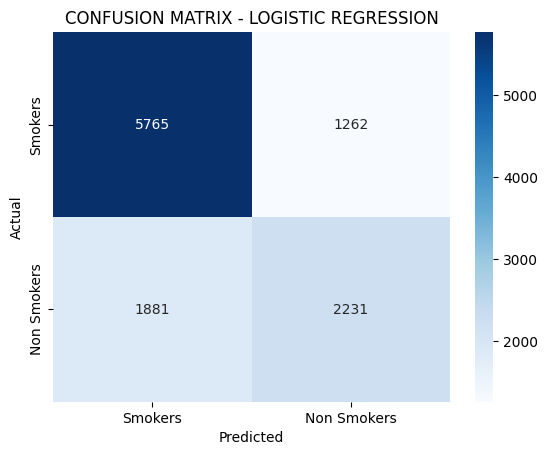

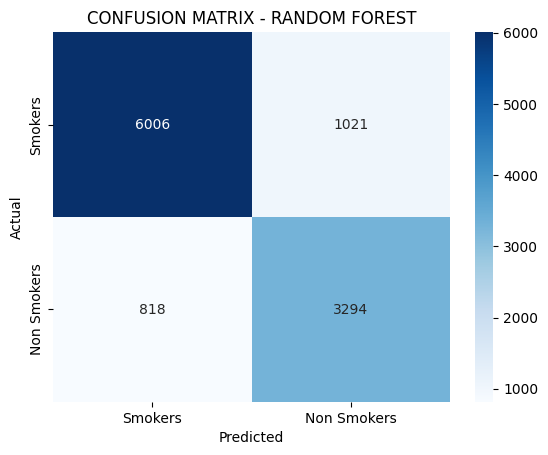

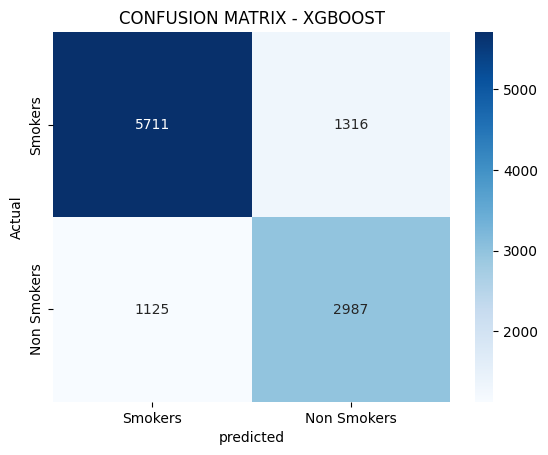

In [38]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = ['Smokers','Non Smokers'],
            yticklabels = ['Smokers','Non Smokers'])
plt.title('CONFUSION MATRIX - LOGISTIC REGRESSION')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm = confusion_matrix(y_test,y_pred_RF)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Smokers','Non Smokers'],
            yticklabels=['Smokers','Non Smokers'])
plt.title('CONFUSION MATRIX - RANDOM FOREST')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm = confusion_matrix(y_test, y_pred_XGB)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels= ['Smokers','Non Smokers'],
            yticklabels= ['Smokers','Non Smokers'])
plt.title('CONFUSION MATRIX - XGBOOST')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.show()


**A deep-dive analysis of the confusion matrices visually validates why Random Forest is the absolute champion model for this dataset. Random Forest demonstrates superior class-separation power by capturing the highest number of True Smokers (6006) and True Non-Smokers (3294), while keeping misclassification errors at an absolute minimum. In stark contrast, Logistic Regression struggles heavily, failing to classify a massive chunk of non-smokers (1881 errors). While XGBoost shows a decent effort by correctly identifying 2987 non-smokers, it still falls short of Random Forest's performance across both classes. Ultimately, Random Forest minimizes both false positives and false negatives most effectively, securing its spot as the most reliable model.**

# **Model Performance Evaluation Using ROC-AUC Analysis**

In [40]:
y_prob_lr = lr_model.predict_proba(X_test)[:,1]
print('LOGISTIC_REGRESSION_ROC_AUC_SCORE:',roc_auc_score(y_test, y_prob_lr))

y_prob_RF = RF_model.predict_proba(X_test)[:,1]
print('RANDOM_FOREST_ROC_AUC_SCOE:',roc_auc_score(y_test,y_prob_RF))

y_prob_XGB = XGB_model.predict_proba(X_test)[:,1]
print('XGB_AOC_AUC_SCORE:',roc_auc_score(y_test,y_prob_XGB))

LOGISTIC_REGRESSION_ROC_AUC_SCORE: 0.8040132446334013
RANDOM_FOREST_ROC_AUC_SCOE: 0.917895690275253
XGB_AOC_AUC_SCORE: 0.8611092345865503


**ROC-AUC Performance Summary:**

**The ROC-AUC analysis further solidifies the definitive superiority of the Random Forest Classifier, achieving an exceptional score of 0.918. In comparison, XGBoost delivers a moderate performance of 0.861, while Logistic Regression trails behind at 0.804. An AUC score of 0.918 demonstrates that Random Forest possesses an outstanding discriminative capability, meaning it has a $91.8\%$ probability of correctly distinguishing between a smoker and a non-smoker across all possible decision thresholds. Consequently, Random Forest is validated as the most robust and accurate model for this dataset.**

- **ROC Comparsion Curve**

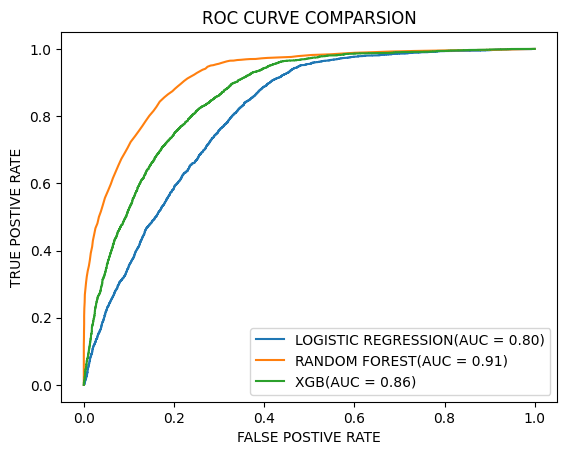

In [49]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1])
RF_fpr, RF_tpr, _= roc_curve(y_test, RF_model.predict_proba(X_test)[:, 1])
XGB_fpr, XGB_tpr, _ = roc_curve(y_test, XGB_model.predict_proba(X_test)[:, 1])
plt.plot(lr_fpr,lr_tpr, label = 'LOGISTIC REGRESSION(AUC = 0.80)')
plt.plot(RF_fpr,RF_tpr, label = 'RANDOM FOREST(AUC = 0.91)')
plt.plot(XGB_fpr, XGB_tpr, label = 'XGB(AUC = 0.86)')
plt.title('ROC CURVE COMPARSION')
plt.xlabel('FALSE POSTIVE RATE')
plt.ylabel('TRUE POSTIVE RATE')
plt.legend()
plt.show()

**Based on our analysis, the ROC Curve comparison clearly highlights the difference in performance among the three models. The Random Forest curve shows the best trajectory, curving sharply toward the top-left corner with an AUC of 0.91, which indicates high reliability in separating smokers from non-smokers. XGBoost takes the middle position with an AUC of 0.86, showing decent stability but falling short of the top performer. Meanwhile, Logistic Regression remains at the bottom with an AUC of 0.80, confirming that it struggles the most with class separation. Overall, the visual alignment confirms that Random Forest provides the most accurate and balanced predictions across all classification thresholds.**

# **FINAL PROJECT CONCLUSION & INSIGHTS:**

1. **OVERALL SUMMARY**

This project uses a large dataset of 55,692 individuals to see how smoking affects different signals and test results in the human body. The main goal is to find out if we can accurately predict a person's smoking habit just by looking at their physical measurements and blood test results, and to see what internal damage smoking causes. After testing three different machine learning models (Logistic Regression, XGBoost, and Random Forest), the Random Forest model came out as the clear winner with 83% accuracy and a top-tier ROC-AUC score of 0.91. This proves that smoking leaves strong, permanent patterns in our body data that data science models can easily detect.

2. **THE PROBLEM: WHY THIS DATA MATTERS**

Smoking causes massive internal damage, but in real life, many people hide or underreport their smoking habits during health checkups or insurance surveys.

 - The Challenge: Doctors and health companies cannot always rely on  what patients say.

 -  The Goal: We want to look at objective biological signals (like blood tests, liver health, and body weight) to catch the hidden footprint of smoking.

 - Real-World Impact: By showing exactly how smoking alters internal organs, we can create automated screening tools that warn people about their health degradation before it turns into a serious disease.

3. **STEPS PERFORMED IN THIS NOTEBOOK**

To complete this analysis, the following data science pipeline was built directly in this notebook:

 - Data Cleaning: Cleaned the data of 55,692 individuals. Dropped useless columns like ID and oral (since it had no changing values) and confirmed there were no missing or duplicate rows.

 - Exploratory Data Analysis (EDA): Used statistical plots (boxplots, histograms, and a correlation heatmap) to understand the differences between smokers and non-smokers.

 - Data Preprocessing: Converted text columns (gender and tartar) into numbers using Label Encoding, and used StandardScaler so that all features are on the same scale for fair modeling.

 - Train-Test Split: Separated the data into 80% for training the models and 20% for testing them on unseen data.

 - Model Building & Testing: Trained Logistic Regression, XGBoost, and Random Forest, and compared them using Confusion Matrices and ROC-AUC curves.

4. **KEY FINDINGS: HOW SMOKING DAMAGING THE BODY**

Our data visualization and analysis revealed some very clear warnings about how smoking affects the body:

 - Smokers Trend Younger: The age boxplot showed that the median age for active smokers is lower than non-smokers. This means younger people in this dataset are actively exposing their bodies to smoking risks, which can lead to early health failure.

 - Liver Stress & Blood Changes: The data shows that smokers have noticeably higher levels of Hemoglobin (blood thickness) and liver enzymes like Gtp and ALT. When someone smokes, the liver has to work extra hard to filter out toxins, which spikes these enzyme scores.

 - Tightly Linked Internal Damage: Our correlation heatmap showed that physical body traits (Weight and Waist: 0.82) and heart health indicators (Cholesterol and LDL/Bad Cholesterol: 0.74) are strongly linked. Smoking puts continuous stress on these connected systems, creating a chain reaction of damage across blood flow and metabolism.

 - Human Errors in Medical Data: The Systolic Blood Pressure graph showed huge, unnatural spikes at exact numbers like 110, 120, and 130. This tells us that medical staff frequently round off blood pressure numbers during busy checkups, which is an important data anomaly to keep in mind.

5. **PRACTICAL RECOMMENDATIONS**

 - Use Automated Digital Screening: Because the data shows human rounding-off errors in blood pressure recordings, medical centers should switch to automated digital tools for 100% accurate health tracking.

 - Focus on Early Screening: Since the data highlights that smokers are generally in the younger age brackets, health awareness programs should target people under 40 to prevent irreversible liver and heart damage early in life.

 - Track Liver and Blood Metrics Together: Health assessments should not just look at a person's lungs. They must monitor combined spikes in Hemoglobin and Gtp (liver enzyme) levels to catch hidden physiological damage caused by smoking.

6. **FINAL MODEL VERDICT**

The journey through this dataset proves that lifestyle habits are clearly written in our biological data. The Random Forest Classifier did an outstanding job of catching these complex, non-linear patterns. It achieved a fantastic ROC-AUC score of 0.91 and made the fewest mistakes, reducing non-smoker misclassifications down to only 818 in its Confusion Matrix. While XGBoost (0.86 AUC) and Logistic Regression (0.80 AUC) performed decently, Random Forest proved to be the most reliable and powerful tool to detect smoking status and flag health risks automatically.